# Credit Card Customer Intelligence Analysis
## A Business Analytics Deep Dive into Spending Behavior, Risk Profiling and Growth Opportunities

**Author:** Harsh Bhatt  
**Dataset:** Credit Card Dataset for Clustering (Kaggle)  
**Tools:** Python, Pandas, Matplotlib, NumPy

---

## Business Problem
A credit card company wants to understand customer behavior to:
- Identify high value customers for premium targeting
- Detect high risk customers showing signs of default
- Find growth opportunities in underutilized segments
- Reduce churn by identifying dormant customers

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully!")

Libraries imported successfully!


In [19]:

df = pd.read_csv('CC GENERAL.csv')


print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (8950, 18)

First 5 rows:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.90,0.82,95.40,0.00,95.40,0.00,0.17,0.00,0.08,0.00,0,2,1000.00,201.80,139.51,0.00,12
1,C10002,3202.47,0.91,0.00,0.00,0.00,6442.95,0.00,0.00,0.00,0.25,4,0,7000.00,4103.03,1072.34,0.22,12
2,C10003,2495.15,1.00,773.17,773.17,0.00,0.00,1.00,1.00,0.00,0.00,0,12,7500.00,622.07,627.28,0.00,12
3,C10004,1666.67,0.64,1499.00,1499.00,0.00,205.79,0.08,0.08,0.00,0.08,1,1,7500.00,0.00,NaN,0.00,12
4,C10005,817.71,1.00,16.00,16.00,0.00,0.00,0.08,0.08,0.00,0.00,0,1,1200.00,678.33,244.79,0.00,12


In [20]:

print("Column Names and Data Types:")
print(df.dtypes)

Column Names and Data Types:
CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


In [21]:

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [22]:

df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())


df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(0)


print("Missing values after cleaning:")
print(df.isnull().sum().sum())
print("\nDataset shape after cleaning:", df.shape)

Missing values after cleaning:
0

Dataset shape after cleaning: (8950, 18)


In [23]:


df['CREDIT_UTILIZATION'] = df['BALANCE'] / df['CREDIT_LIMIT']


df['PAYMENT_RATIO'] = df['PAYMENTS'] / (df['MINIMUM_PAYMENTS'] + 1)

print("New columns added successfully!")
print("Dataset shape now:", df.shape)

New columns added successfully!
Dataset shape now: (8950, 20)


In [24]:


print("Statistical Summary:")
df.describe()

Statistical Summary:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,CREDIT_UTILIZATION,PAYMENT_RATIO
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00
mean,1564.47,0.88,1003.20,592.44,411.07,978.87,0.49,0.20,0.36,0.14,3.25,14.71,4494.28,1733.14,833.98,0.15,11.52,0.39,17.63
std,2081.53,0.24,2136.63,1659.89,904.34,2097.16,0.40,0.30,0.40,0.20,6.82,24.86,3638.65,2895.06,2335.99,0.29,1.34,0.39,378.65
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.00,0.00,0.00,0.00,6.00,0.00,0.00
25%,128.28,0.89,39.63,0.00,0.00,0.00,0.08,0.00,0.00,0.00,0.00,1.00,1600.00,383.28,163.03,0.00,12.00,0.04,0.92
50%,873.39,1.00,361.28,38.00,89.00,0.00,0.50,0.08,0.17,0.00,0.00,7.00,3000.00,856.90,289.63,0.00,12.00,0.30,2.07
75%,2054.14,1.00,1110.13,577.40,468.64,1113.82,0.92,0.30,0.75,0.22,4.00,17.00,6500.00,1901.13,788.71,0.14,12.00,0.72,6.20
max,19043.14,1.00,49039.57,40761.25,22500.00,47137.21,1.00,1.00,1.00,1.50,123.00,358.00,30000.00,50721.48,76406.21,1.00,12.00,15.91,29272.49


In [25]:


def segment_customer(row):
    if row['PURCHASES_FREQUENCY'] < 0.2 and row['CASH_ADVANCE_FREQUENCY'] < 0.2:
        return 'Dormant'
    elif row['CASH_ADVANCE_FREQUENCY'] > 0.4 and row['PRC_FULL_PAYMENT'] < 0.2:
        return 'Cash Advance Dependent'
    elif row['PRC_FULL_PAYMENT'] > 0.6:
        return 'High Value Active'
    else:
        return 'Revolver'

df['CUSTOMER_SEGMENT'] = df.apply(segment_customer, axis=1)

print("Customer Segment Distribution:")
print(df['CUSTOMER_SEGMENT'].value_counts())
print("\nPercentage Distribution:")
print(df['CUSTOMER_SEGMENT'].value_counts(normalize=True).mul(100).round(2))

Customer Segment Distribution:
CUSTOMER_SEGMENT
Revolver                  5054
Dormant                   1943
Cash Advance Dependent    1000
High Value Active          953
Name: count, dtype: int64

Percentage Distribution:
CUSTOMER_SEGMENT
Revolver                 56.47
Dormant                  21.71
Cash Advance Dependent   11.17
High Value Active        10.65
Name: proportion, dtype: float64


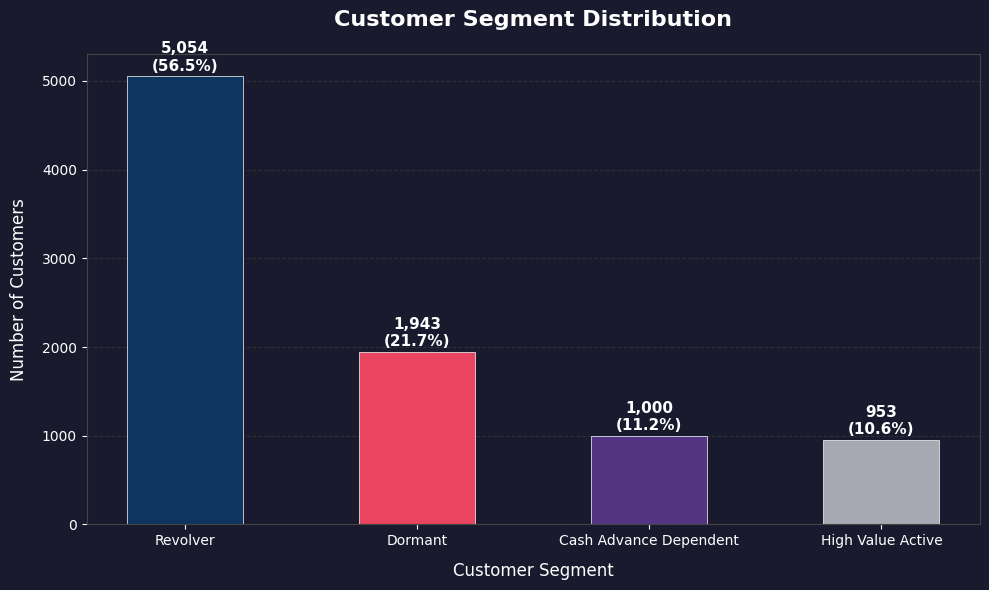

Chart saved!


In [26]:

segments = df['CUSTOMER_SEGMENT'].value_counts()
colors = ['#0f3460', '#e94560', '#533483', '#a8a8b3']


fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars = ax.bar(segments.index, segments.values, color=colors, width=0.5, edgecolor='white', linewidth=0.5)


for bar, val in zip(bars, segments.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')


ax.set_title('Customer Segment Distribution', color='white', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Customer Segment', color='white', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Customers', color='white', fontsize=12, labelpad=10)
ax.tick_params(colors='white', labelsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')
ax.yaxis.grid(True, color='#444444', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("Chart saved!")

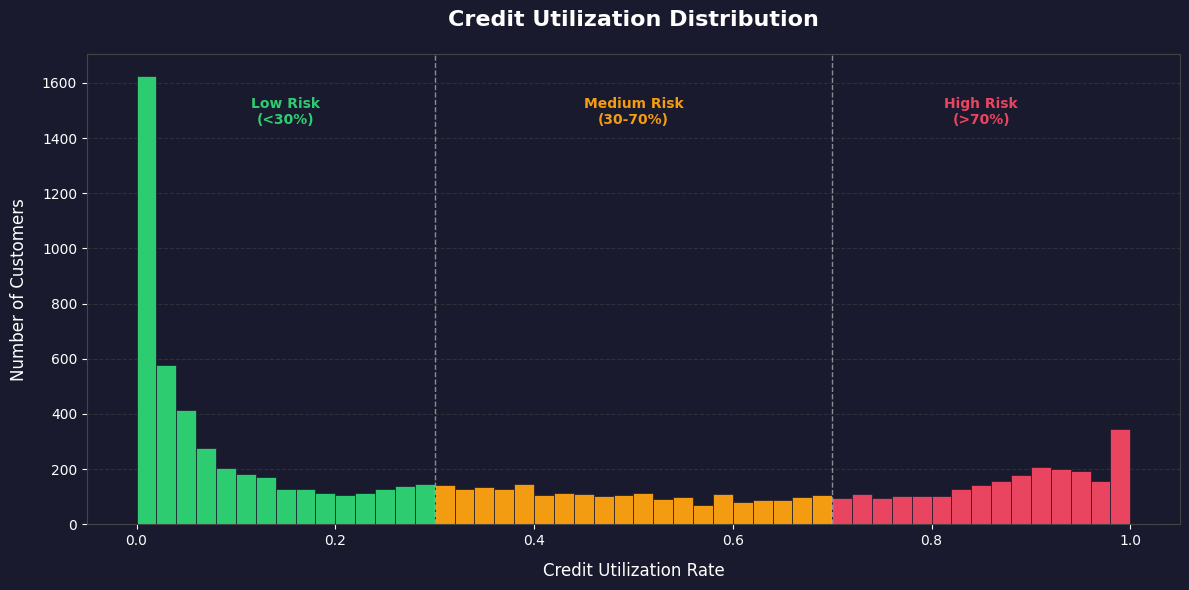

Chart saved!


In [28]:

util_data = df['CREDIT_UTILIZATION'].clip(upper=1.0)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')


n, bins, patches = ax.hist(util_data, bins=50, edgecolor='#1a1a2e', linewidth=0.5)


for patch, left_edge in zip(patches, bins):
    if left_edge < 0.3:
        patch.set_facecolor('#2ecc71')
    elif left_edge < 0.7:
        patch.set_facecolor('#f39c12')
    else:
        patch.set_facecolor('#e94560')


ax.axvline(x=0.3, color='white', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=0.7, color='white', linestyle='--', alpha=0.5, linewidth=1)


ymax = ax.get_ylim()[1]
ax.text(0.15, ymax * 0.85, 'Low Risk\n(<30%)', color='#2ecc71',
        fontsize=10, ha='center', fontweight='bold')
ax.text(0.50, ymax * 0.85, 'Medium Risk\n(30-70%)', color='#f39c12',
        fontsize=10, ha='center', fontweight='bold')
ax.text(0.85, ymax * 0.85, 'High Risk\n(>70%)', color='#e94560',
        fontsize=10, ha='center', fontweight='bold')


ax.set_title('Credit Utilization Distribution', color='white',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Credit Utilization Rate', color='white', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Customers', color='white', fontsize=12, labelpad=10)
ax.tick_params(colors='white', labelsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')
ax.yaxis.grid(True, color='#444444', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('credit_utilization.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("Chart saved!")

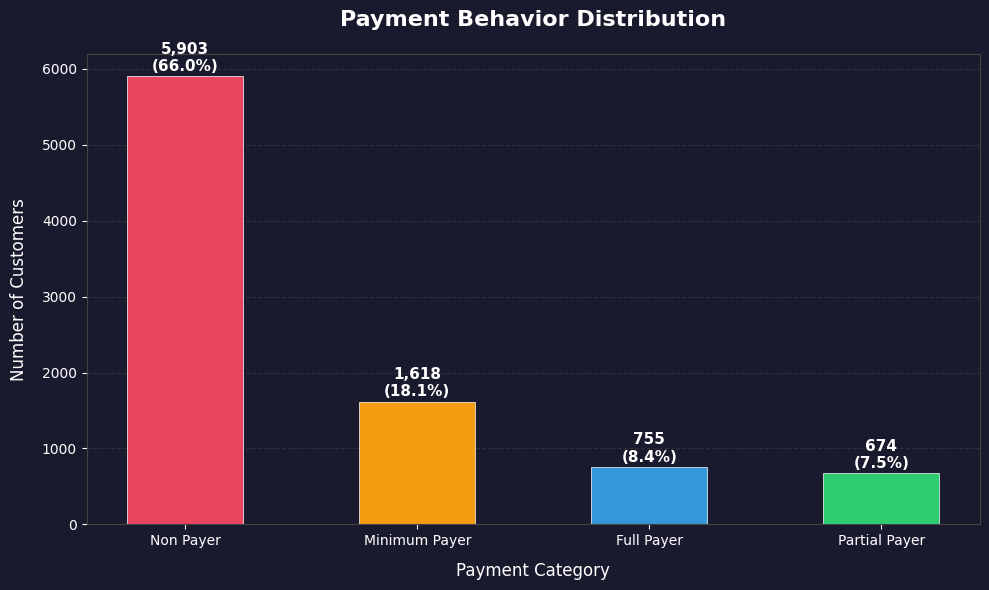

Chart saved!


In [29]:

def payment_category(prc):
    if prc >= 0.8:
        return 'Full Payer'
    elif prc >= 0.4:
        return 'Partial Payer'
    elif prc > 0:
        return 'Minimum Payer'
    else:
        return 'Non Payer'

df['PAYMENT_BEHAVIOR'] = df['PRC_FULL_PAYMENT'].apply(payment_category)

payment_counts = df['PAYMENT_BEHAVIOR'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

colors = ['#e94560', '#f39c12', '#3498db', '#2ecc71']
bars = ax.bar(payment_counts.index, payment_counts.values, 
              color=colors, width=0.5, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, payment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')

ax.set_title('Payment Behavior Distribution', color='white',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Payment Category', color='white', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Customers', color='white', fontsize=12, labelpad=10)
ax.tick_params(colors='white', labelsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')
ax.yaxis.grid(True, color='#444444', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('payment_behavior.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("Chart saved!")

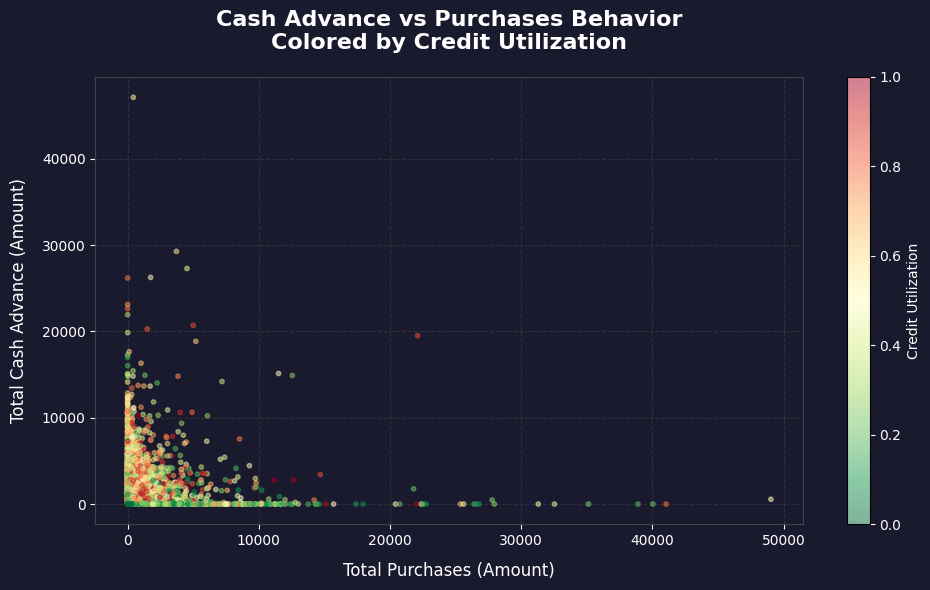

Chart saved!


In [30]:

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')


scatter = ax.scatter(df['PURCHASES'], df['CASH_ADVANCE'],
                    c=df['CREDIT_UTILIZATION'].clip(upper=1.0),
                    cmap='RdYlGn_r',
                    alpha=0.5, s=10)


cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Credit Utilization', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')


ax.set_title('Cash Advance vs Purchases Behavior\nColored by Credit Utilization',
             color='white', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Purchases (Amount)', color='white', fontsize=12, labelpad=10)
ax.set_ylabel('Total Cash Advance (Amount)', color='white', fontsize=12, labelpad=10)
ax.tick_params(colors='white', labelsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')
ax.yaxis.grid(True, color='#444444', linestyle='--', alpha=0.5)
ax.xaxis.grid(True, color='#444444', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('cash_advance_vs_purchases.png', dpi=150, 
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("Chart saved!")

C:\Users\Harsh\AppData\Local\Temp\ipykernel_28228\1009048637.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(segment_metrics.index, rotation=15, ha='right')
C:\Users\Harsh\AppData\Local\Temp\ipykernel_28228\1009048637.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(segment_metrics.index, rotation=15, ha='right')
C:\Users\Harsh\AppData\Local\Temp\ipykernel_28228\1009048637.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(segment_metrics.index, rotation=15, ha='right')


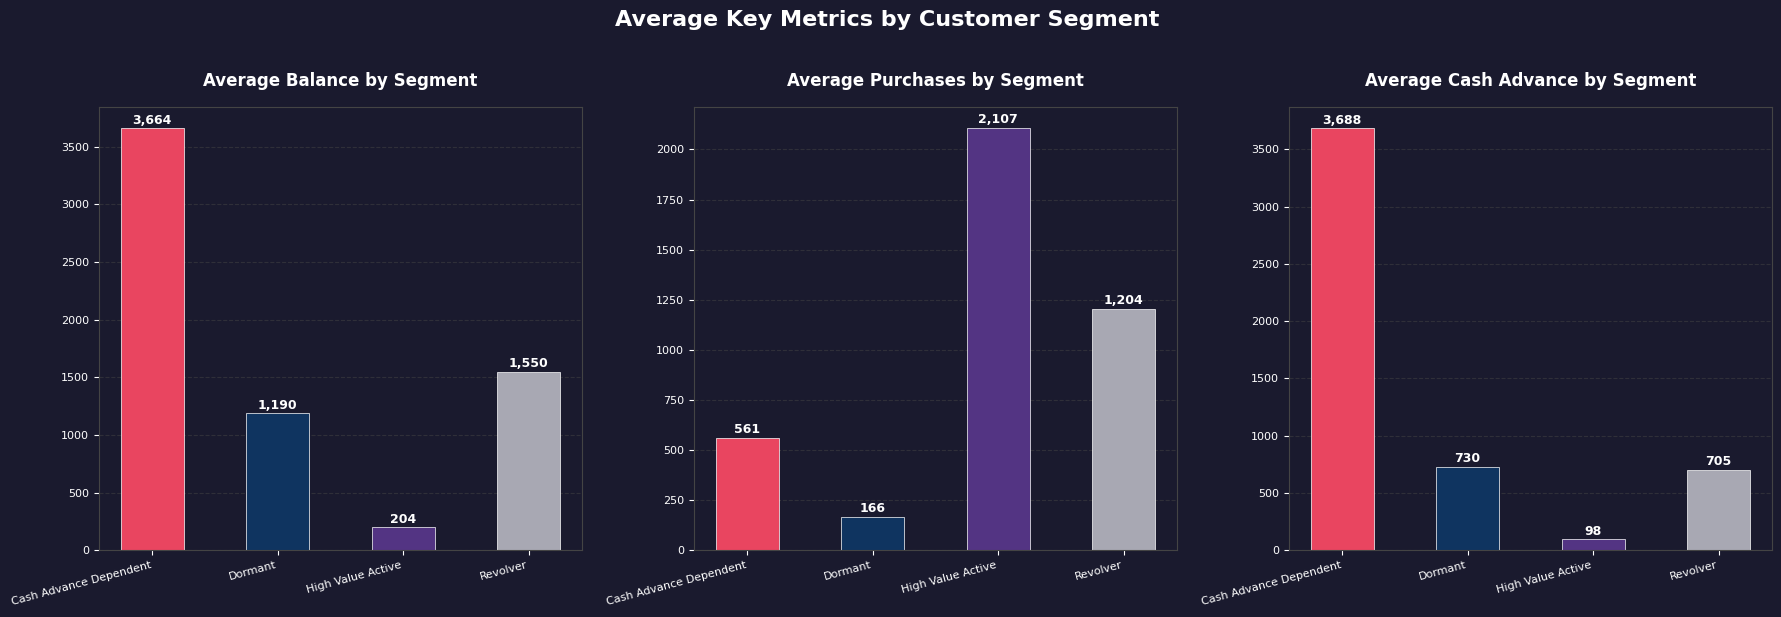

Chart saved!


In [31]:

segment_metrics = df.groupby('CUSTOMER_SEGMENT').agg({
    'BALANCE': 'mean',
    'PURCHASES': 'mean',
    'CASH_ADVANCE': 'mean',
    'CREDIT_UTILIZATION': 'mean',
    'PRC_FULL_PAYMENT': 'mean'
}).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#1a1a2e')

metrics = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE']
titles = ['Average Balance by Segment', 
          'Average Purchases by Segment', 
          'Average Cash Advance by Segment']
colors = ['#e94560', '#0f3460', '#533483', '#a8a8b3']

for ax, metric, title in zip(axes, metrics, titles):
    ax.set_facecolor('#1a1a2e')
    bars = ax.bar(segment_metrics.index, segment_metrics[metric],
                  color=colors, width=0.5, edgecolor='white', linewidth=0.5)
    
    for bar, val in zip(bars, segment_metrics[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,.0f}', ha='center', va='bottom', 
                color='white', fontsize=9, fontweight='bold')
    
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=15)
    ax.tick_params(colors='white', labelsize=8)
    ax.set_xticklabels(segment_metrics.index, rotation=15, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')
    ax.yaxis.grid(True, color='#444444', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.suptitle('Average Key Metrics by Customer Segment', 
             color='white', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('segment_metrics.png', dpi=150, 
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("Chart saved!")

## Key Findings & Business Recommendations

### Finding 1: Majority of Customers are Revolvers (56.47%)
**Insight:** More than half the customer base carries a balance and never pays in full.
**Recommendation:** Launch targeted financial wellness programs and balance reduction incentives to gradually move Revolvers toward full payment behavior, reducing long term default risk while maintaining engagement.

### Finding 2: 66% of Customers are Non-Payers of Full Balance
**Insight:** Only 15% of customers on average pay their full balance — generating consistent interest revenue but creating portfolio vulnerability.
**Recommendation:** Introduce flexible payment plans and automated payment reminders to improve payment rates, reducing risk concentration.

### Finding 3: Cash Advance Dependent Customers are High Risk
**Insight:** 1,000 customers (11.17%) rely heavily on cash advances with high balances and low full payment rates.
**Recommendation:** Flag this segment for credit risk monitoring, consider credit limit reviews, and offer alternative financial products like personal loans at lower interest rates to reduce cash advance dependency.

### Finding 4: High Value Active Segment is Underleveraged (10.65%)
**Insight:** Only 953 customers represent the ideal profile — high spending, full payment, low risk.
**Recommendation:** Prioritize retention of this segment through premium rewards programs, exclusive offers, and credit limit increases to drive higher spending volume without increasing risk.

### Finding 5: 21.71% of Customers are Dormant
**Insight:** Nearly 1 in 5 customers barely uses their card — representing churn risk and lost revenue opportunity.
**Recommendation:** Launch re-engagement campaigns with personalized offers based on past spending behavior to reactivate dormant customers before they cancel.